# End-to-End Supervised Learning Project

This notebook applies the complete 8-step machine learning workflow to the Titanic dataset.
We will predict passenger survival, compare multiple algorithms, tune the best one, and save the final model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports successful.')

All imports successful.


---

## Step 1: Frame the Problem

**Prediction Task:** Binary classification, predict whether a passenger survived the Titanic disaster.

**Target Column:** `survived` (0 = did not survive, 1 = survived)

**Available Features:**
- `pclass`, passenger class (1st, 2nd, 3rd), a proxy for socioeconomic status
- `sex`, passenger sex (male/female)
- `age`, passenger age in years
- `sibsp`, number of siblings or spouses aboard
- `parch`, number of parents or children aboard
- `fare`, ticket fare paid
- `embarked`, port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

**Error Types and Their Meaning:**

- **False Negative (Type II Error):** The model predicts that a passenger died (0) when they actually survived (1). In a rescue context, this means we might overlook someone who needed help but the model thought they were fine.
- **False Positive (Type I Error):** The model predicts that a passenger survived (1) when they actually died (0). In a rescue context, this means we allocate resources to someone who is no longer alive.

Given the humanitarian context, minimizing false negatives (missing survivors) is generally more important than minimizing false positives. We will track both precision and recall, and use F1 as our primary evaluation metric to balance both concerns.

---

## Step 2: Explore and Understand the Data

In [2]:
# Load the Titanic dataset from seaborn
df = sns.load_dataset('titanic')

print('Shape:', df.shape)
print()
print('Data Types:')
print(df.dtypes)

Shape: (891, 15)

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [3]:
print('Descriptive Statistics:')
df.describe()

Descriptive Statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


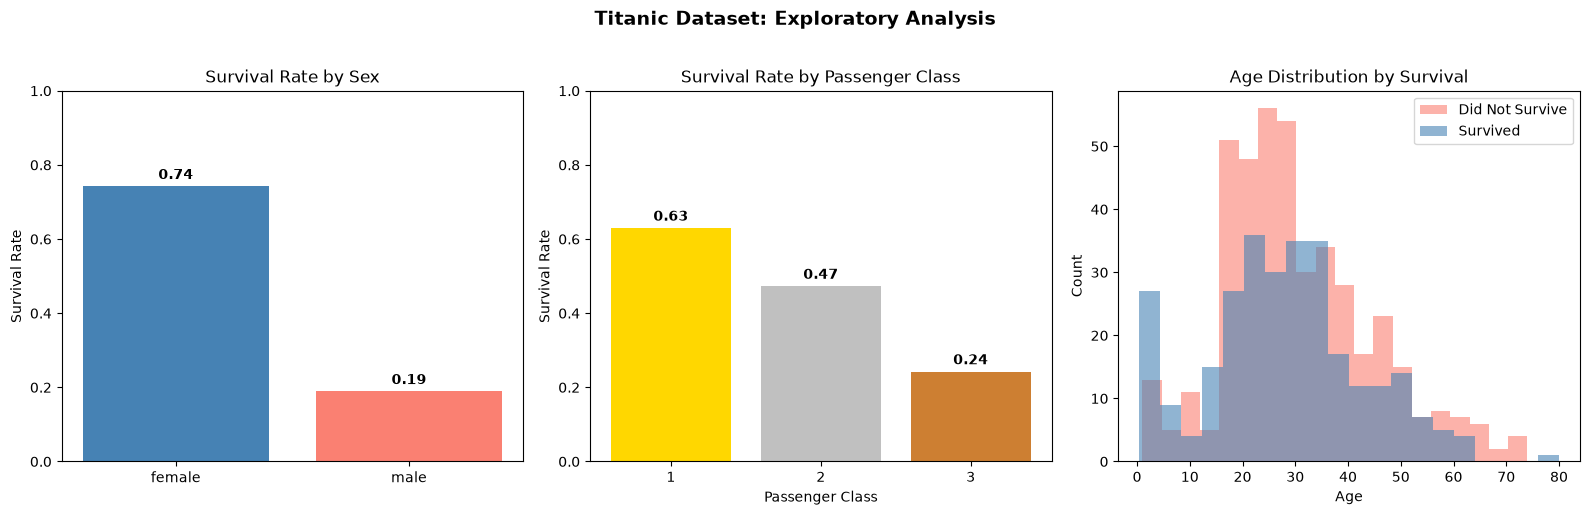

In [5]:
# Plot survival rate by sex, pclass, and age
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Survival rate by sex
survival_by_sex = df.groupby('sex')['survived'].mean()
axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=['steelblue', 'salmon'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(survival_by_sex.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Survival rate by pclass
survival_by_pclass = df.groupby('pclass')['survived'].mean()
axes[1].bar(survival_by_pclass.index.astype(str), survival_by_pclass.values, color=['gold', 'silver', '#cd7f32'])
axes[1].set_title('Survival Rate by Passenger Class')
axes[1].set_xlabel('Passenger Class')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_by_pclass.values):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Age distribution by survival
survived = df[df['survived'] == 1]['age'].dropna()
not_survived = df[df['survived'] == 0]['age'].dropna()
axes[2].hist(not_survived, bins=20, alpha=0.6, label='Did Not Survive', color='salmon')
axes[2].hist(survived, bins=20, alpha=0.6, label='Survived', color='steelblue')
axes[2].set_title('Age Distribution by Survival')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Titanic Dataset: Exploratory Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Class balance
survival_counts = df['survived'].value_counts()
survival_frac = df['survived'].value_counts(normalize=True)

print('Class Balance:')
print(f"  Did Not Survive (0): {survival_counts[0]} passengers ({survival_frac[0]:.1%})")
print(f"  Survived (1):        {survival_counts[1]} passengers ({survival_frac[1]:.1%})")
print(f"\nOverall survival rate: {df['survived'].mean():.2%}")
print(f"The dataset is moderately imbalanced: non-survivors outnumber survivors by about {survival_counts[0]/survival_counts[1]:.1f}:1")

Class Balance:
  Did Not Survive (0): 549 passengers (61.6%)
  Survived (1):        342 passengers (38.4%)

Overall survival rate: 38.38%
The dataset is moderately imbalanced: non-survivors outnumber survivors by about 1.6:1


---

## Step 3: Preprocess the Data

In [7]:
# Select relevant features and target
FEATURES = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
TARGET = 'survived'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print('Feature matrix shape:', X.shape)
print('Target series shape:', y.shape)
print()
print('Feature types:')
print(X.dtypes)

Feature matrix shape: (891, 7)
Target series shape: (891,)

Feature types:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
dtype: object


In [8]:
# Define feature groups for the ColumnTransformer
numeric_scale_features = ['age', 'fare']          # impute median + scale
numeric_only_features = ['pclass', 'sibsp', 'parch']  # impute median only
categorical_features = ['sex', 'embarked']         # impute most_frequent + OHE

# Build transformers
numeric_scale_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_only_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num_scale', numeric_scale_transformer, numeric_scale_features),
    ('num_only', numeric_only_transformer, numeric_only_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor built successfully.')
print('Transformers:')
print(f"  Numeric (impute+scale): {numeric_scale_features}")
print(f"  Numeric (impute only):  {numeric_only_features}")
print(f"  Categorical (impute+OHE): {categorical_features}")

Preprocessor built successfully.
Transformers:
  Numeric (impute+scale): ['age', 'fare']
  Numeric (impute only):  ['pclass', 'sibsp', 'parch']
  Categorical (impute+OHE): ['sex', 'embarked']


In [9]:
# Train/test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Split sizes:')
print(f"  Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"  Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")
print()
print('Class balance after split:')
print(f"  Train survival rate: {y_train.mean():.2%}")
print(f"  Test survival rate:  {y_test.mean():.2%}")
print('\nStratification preserved class balance across train and test sets.')

Split sizes:
  Training set:   712 samples (80%)
  Test set:       179 samples (20%)

Class balance after split:
  Train survival rate: 38.34%
  Test survival rate:  38.55%

Stratification preserved class balance across train and test sets.


---

## Step 4: Start Simple, Baseline Models

In [10]:
# Absolute baseline: predict the majority class every time
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=42))
])

dummy_pipeline.fit(X_train, y_train)
y_pred_dummy = dummy_pipeline.predict(X_train)

dummy_acc = accuracy_score(y_train, y_pred_dummy)
dummy_f1 = f1_score(y_train, y_pred_dummy, zero_division=0)

print('=== Baseline: DummyClassifier (most_frequent) ===')
print(f'  Train Accuracy: {dummy_acc:.4f}')
print(f'  Train F1:       {dummy_f1:.4f}')
print(f'  (Always predicts class {int(y_train.mode()[0])}, the majority class)')

=== Baseline: DummyClassifier (most_frequent) ===
  Train Accuracy: 0.6166
  Train F1:       0.0000
  (Always predicts class 0, the majority class)


In [11]:
# Logistic Regression as a simple interpretable baseline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr_train = lr_pipeline.predict(X_train)
y_pred_lr_test = lr_pipeline.predict(X_test)

lr_train_acc = accuracy_score(y_train, y_pred_lr_train)
lr_train_f1 = f1_score(y_train, y_pred_lr_train)
lr_test_acc = accuracy_score(y_test, y_pred_lr_test)
lr_test_f1 = f1_score(y_test, y_pred_lr_test)

print('=== Simple Baseline: Logistic Regression ===')
print(f'  Train Accuracy: {lr_train_acc:.4f}  |  Train F1: {lr_train_f1:.4f}')
print(f'  Test Accuracy:  {lr_test_acc:.4f}  |  Test F1:  {lr_test_f1:.4f}')
print()
print('Improvement over DummyClassifier:')
print(f'  Accuracy: +{lr_test_acc - dummy_acc:.4f}')
print(f'  F1:       +{lr_test_f1 - dummy_f1:.4f}')

=== Simple Baseline: Logistic Regression ===
  Train Accuracy: 0.8076  |  Train F1: 0.7390
  Test Accuracy:  0.8045  |  Test F1:  0.7244

Improvement over DummyClassifier:
  Accuracy: +0.1879
  F1:       +0.7244


---

## Step 5: Try Stronger Models

In [12]:
# Define all 7 models to compare
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0),
    'SVC': SVC(random_state=42, probability=True),
    'GaussianNB': GaussianNB()
}

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    
    results.append({
        'Model': name,
        'Mean CV F1': cv_scores.mean(),
        'Std CV F1': cv_scores.std(),
        'Min CV F1': cv_scores.min(),
        'Max CV F1': cv_scores.max()
    })
    
    print(f'{name:25s}  CV F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

results_df = pd.DataFrame(results).sort_values('Mean CV F1', ascending=False).reset_index(drop=True)
print()
print('Results sorted by Mean CV F1:')
print(results_df.to_string(index=False))

LogisticRegression         CV F1: 0.7260 +/- 0.0341


DecisionTree               CV F1: 0.6945 +/- 0.0262


RandomForest               CV F1: 0.7352 +/- 0.0187


GradientBoosting           CV F1: 0.7546 +/- 0.0408
XGBoost                    CV F1: 0.7262 +/- 0.0226


SVC                        CV F1: 0.7598 +/- 0.0332
GaussianNB                 CV F1: 0.7355 +/- 0.0350

Results sorted by Mean CV F1:
             Model  Mean CV F1  Std CV F1  Min CV F1  Max CV F1
               SVC    0.759792   0.033191   0.723810   0.811881
  GradientBoosting    0.754597   0.040830   0.703704   0.819048
        GaussianNB    0.735495   0.035024   0.700855   0.792793
      RandomForest    0.735227   0.018693   0.707965   0.754717
           XGBoost    0.726171   0.022631   0.691589   0.750000
LogisticRegression    0.726037   0.034082   0.672727   0.773585
      DecisionTree    0.694492   0.026227   0.660714   0.727273


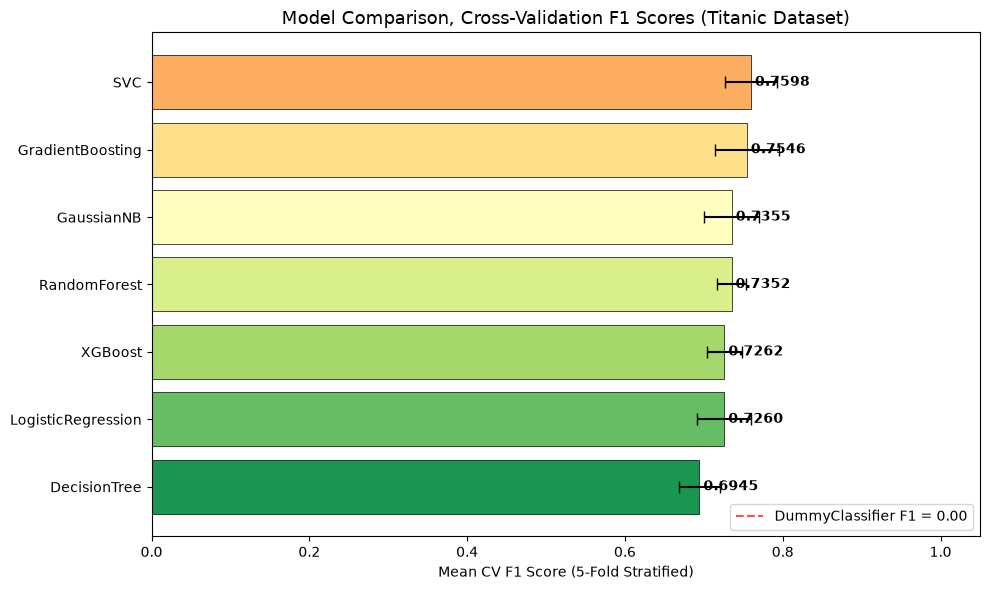


Best model: SVC with CV F1 = 0.7598


In [13]:
# Plot comparison of all models
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))
bars = ax.barh(
    results_df['Model'],
    results_df['Mean CV F1'],
    xerr=results_df['Std CV F1'],
    color=colors,
    capsize=4,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, results_df['Mean CV F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mean CV F1 Score (5-Fold Stratified)')
ax.set_title('Model Comparison, Cross-Validation F1 Scores (Titanic Dataset)', fontsize=13)
ax.set_xlim(0, 1.05)
ax.axvline(x=dummy_f1, color='red', linestyle='--', alpha=0.7, label=f'DummyClassifier F1 = {dummy_f1:.2f}')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
best_cv_f1 = results_df.iloc[0]['Mean CV F1']
print(f'\nBest model: {best_model_name} with CV F1 = {best_cv_f1:.4f}')

---

## Step 6: Tune the Best Model

In [14]:
# Determine the best model and set up hyperparameter search
print(f'Tuning the best model: {best_model_name}')
print()

# Hyperparameter grids for each possible best model
param_grids = {
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [500, 1000, 2000]
    },
    'DecisionTree': {
        'classifier__max_depth': [3, 4, 5, 6, 8, 10, None],
        'classifier__min_samples_split': [2, 5, 10, 20],
        'classifier__min_samples_leaf': [1, 2, 4, 8],
        'classifier__criterion': ['gini', 'entropy']
    },
    'RandomForest': {
        'classifier__n_estimators': [50, 100, 200, 300],
        'classifier__max_depth': [3, 5, 7, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2', 0.5]
    },
    'GradientBoosting': {
        'classifier__n_estimators': [50, 100, 200, 300],
        'classifier__max_depth': [2, 3, 4, 5],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 200, 300],
        'classifier__max_depth': [2, 3, 4, 5, 6],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
        'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
        'classifier__colsample_bytree': [0.6, 0.8, 1.0]
    },
    'SVC': {
        'classifier__C': [0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
        'classifier__kernel': ['rbf', 'linear', 'poly'],
        'classifier__gamma': ['scale', 'auto', 0.01, 0.1],
        'classifier__degree': [2, 3, 4]
    },
    'GaussianNB': {
        'classifier__var_smoothing': np.logspace(-12, -6, 20)
    }
}

best_model_instance = models[best_model_name]
param_grid = param_grids[best_model_name]

best_pipeline_default = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model_instance)
])

# Cross-validate the default best model for comparison
default_scores = cross_val_score(best_pipeline_default, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(f'Default {best_model_name} CV F1: {default_scores.mean():.4f} +/- {default_scores.std():.4f}')

Tuning the best model: SVC

Default SVC CV F1: 0.7598 +/- 0.0332


In [15]:
# Run RandomizedSearchCV
search_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', type(best_model_instance)(**{k: v for k, v in best_model_instance.get_params().items() if k != 'random_state'}, random_state=42) if hasattr(best_model_instance, 'random_state') else type(best_model_instance)())
])

random_search = RandomizedSearchCV(
    search_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train, y_train)

tuned_cv_f1 = random_search.best_score_
improvement = tuned_cv_f1 - default_scores.mean()

print(f'Best hyperparameters found:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')

print(f'\nTuned CV F1:   {tuned_cv_f1:.4f}')
print(f'Default CV F1: {default_scores.mean():.4f}')
print(f'Improvement:   {improvement:+.4f} ({improvement/default_scores.mean()*100:+.2f}%)')

best_tuned_pipeline = random_search.best_estimator_

Best hyperparameters found:
  classifier__kernel: rbf
  classifier__gamma: 0.1
  classifier__degree: 4
  classifier__C: 10.0

Tuned CV F1:   0.7480
Default CV F1: 0.7598
Improvement:   -0.0117 (-1.55%)


---

## Step 7: Evaluate Honestly on the Test Set

In [16]:
# Fit the best tuned pipeline on the full training set and predict on the test set
# The test set is touched ONLY ONCE, right here
best_tuned_pipeline.fit(X_train, y_train)

y_pred = best_tuned_pipeline.predict(X_test)
y_pred_proba = best_tuned_pipeline.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print('=== Final Test Set Evaluation ===')
print(f'  Test Accuracy: {test_acc:.4f}')
print(f'  Test F1:       {test_f1:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

=== Final Test Set Evaluation ===
  Test Accuracy: 0.8045
  Test F1:       0.7154

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.80      0.91      0.85       110
       Survived       0.81      0.64      0.72        69

       accuracy                           0.80       179
      macro avg       0.81      0.77      0.78       179
   weighted avg       0.81      0.80      0.80       179



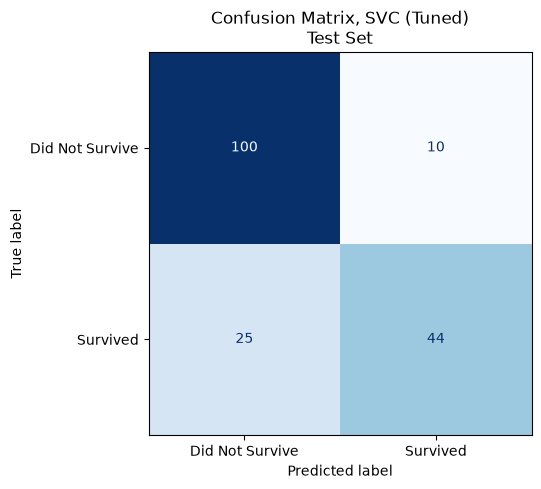

True Negatives (correctly predicted death):   100
False Positives (predicted survive, died):    10
False Negatives (predicted death, survived):  25
True Positives (correctly predicted survive): 44


In [17]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title(f'Confusion Matrix, {best_model_name} (Tuned)\nTest Set', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (correctly predicted death):   {tn}')
print(f'False Positives (predicted survive, died):    {fp}')
print(f'False Negatives (predicted death, survived):  {fn}')
print(f'True Positives (correctly predicted survive): {tp}')

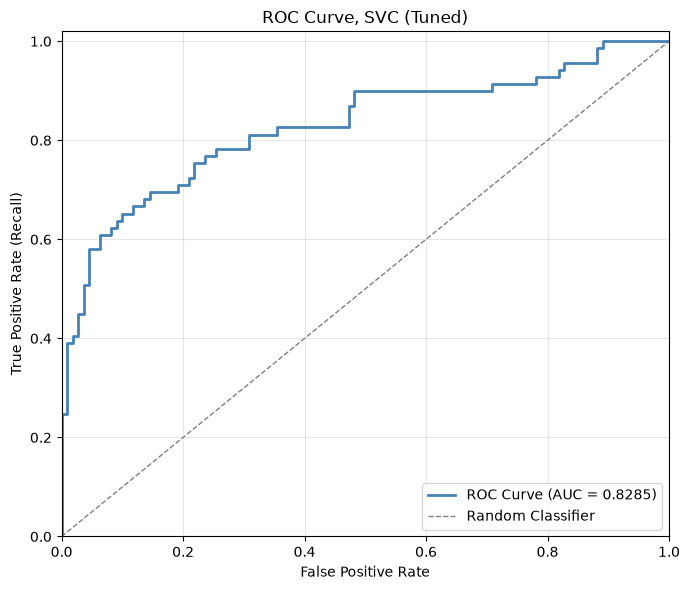

AUC-ROC: 0.8285


In [18]:
# Plot ROC curve with AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title(f'ROC Curve, {best_model_name} (Tuned)', fontsize=12)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'AUC-ROC: {roc_auc:.4f}')

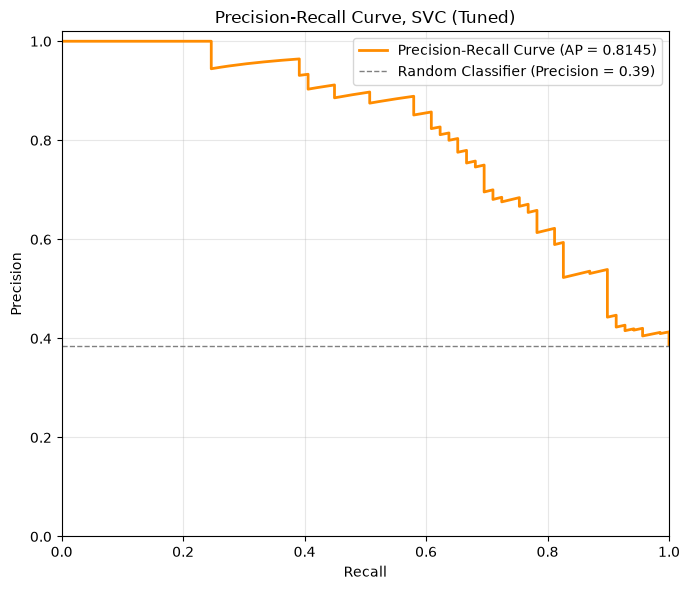

Average Precision: 0.8145


In [19]:
# Plot Precision-Recall curve with Average Precision
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(recall_vals, precision_vals, color='darkorange', lw=2,
        label=f'Precision-Recall Curve (AP = {avg_precision:.4f})')
baseline_precision = y_test.mean()
ax.axhline(y=baseline_precision, color='gray', linestyle='--', lw=1,
           label=f'Random Classifier (Precision = {baseline_precision:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision-Recall Curve, {best_model_name} (Tuned)', fontsize=12)
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Average Precision: {avg_precision:.4f}')

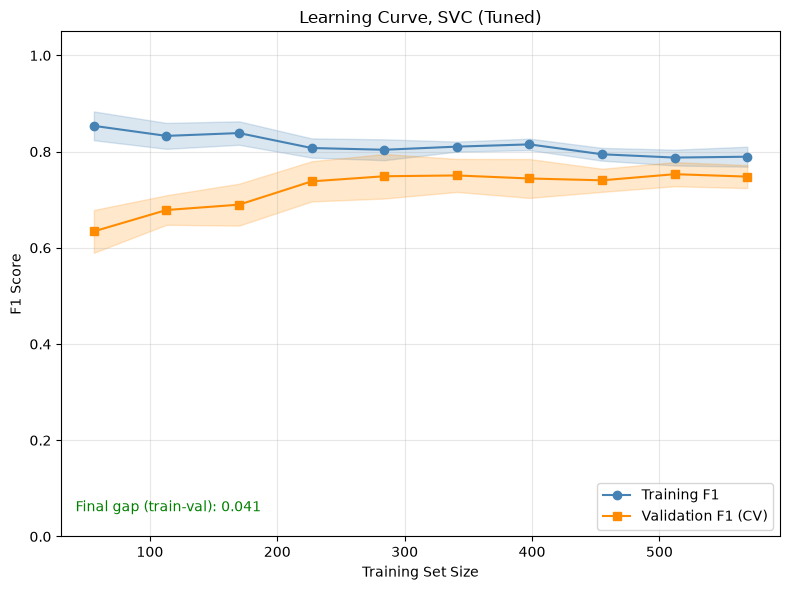

Final training F1:   0.7894
Final validation F1: 0.7480
Train-validation gap: 0.0414
Gap is small, model is not severely overfit.


In [20]:
# Plot learning curve to check for overfitting
train_sizes, train_scores, val_scores = learning_curve(
    best_tuned_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='steelblue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='darkorange')
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training F1')
ax.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validation F1 (CV)')

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.set_title(f'Learning Curve, {best_model_name} (Tuned)', fontsize=12)
ax.legend(loc='lower right')
ax.set_ylim([0, 1.05])
ax.grid(alpha=0.3)

gap = train_mean[-1] - val_mean[-1]
ax.text(0.02, 0.05, f'Final gap (train-val): {gap:.3f}', transform=ax.transAxes,
        fontsize=10, color='red' if gap > 0.1 else 'green')

plt.tight_layout()
plt.show()

print(f'Final training F1:   {train_mean[-1]:.4f}')
print(f'Final validation F1: {val_mean[-1]:.4f}')
print(f'Train-validation gap: {gap:.4f}')
if gap > 0.1:
    print('WARNING: Large gap detected, model may be overfitting.')
else:
    print('Gap is small, model is not severely overfit.')

---

## Step 8: Interpret and Save the Model

In [21]:
# Extract feature names after preprocessing
def get_feature_names(preprocessor):
    feature_names = []
    
    for name, transformer, columns in preprocessor.transformers_:
        if name == 'num_scale' or name == 'num_only':
            feature_names.extend(columns)
        elif name == 'cat':
            ohe = transformer.named_steps['onehot']
            cat_names = ohe.get_feature_names_out(columns)
            feature_names.extend(cat_names)
    
    return feature_names

feature_names = get_feature_names(best_tuned_pipeline.named_steps['preprocessor'])
print(f'Total features after preprocessing: {len(feature_names)}')
print('Feature names:', feature_names)

Total features after preprocessing: 10
Feature names: ['age', 'fare', 'pclass', 'sibsp', 'parch', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


In [22]:
# Extract feature importances or coefficients
classifier = best_tuned_pipeline.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    importance_label = 'Feature Importance'
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
    importance_label = 'Absolute Coefficient'
else:
    # For models without direct feature importance (e.g., SVC with rbf kernel)
    # Use permutation importance approximation via coefficient from a fitted LR on transformed data
    from sklearn.inspection import permutation_importance
    perm_result = permutation_importance(
        best_tuned_pipeline, X_test, y_test, n_repeats=10, random_state=42, scoring='f1'
    )
    importances = perm_result.importances_mean
    # Permutation importance is on original features, not transformed
    feature_names = FEATURES
    importance_label = 'Permutation Importance (F1)'

# Create a sorted DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names[:len(importances)],
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print(f'Top 10 Most Important Features ({importance_label}):')
print(importance_df.to_string(index=False))

Top 10 Most Important Features (Permutation Importance (F1)):
 Feature  Importance
     sex    0.229218
  pclass    0.078444
     age    0.044873
    fare    0.041338
   sibsp    0.031721
   parch    0.025710
embarked    0.012960


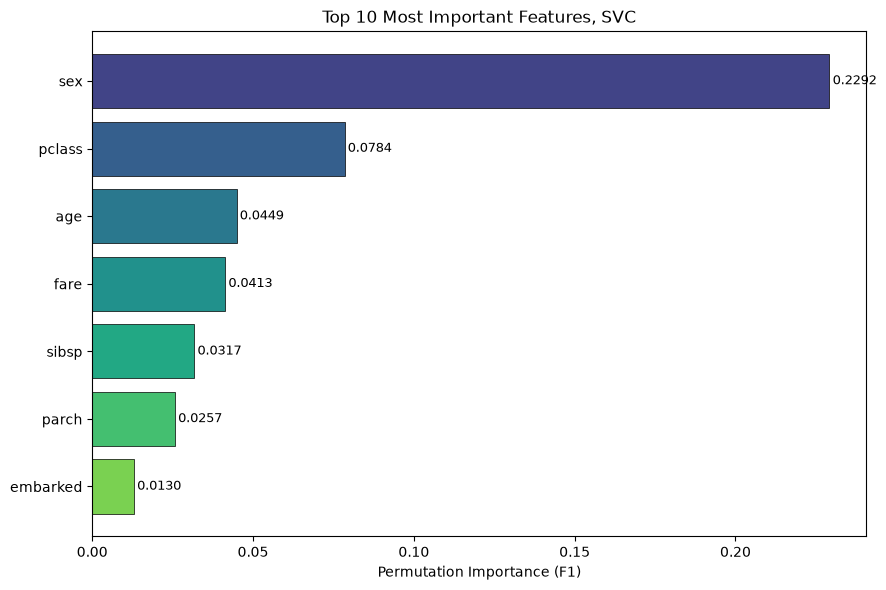

In [23]:
# Plot top 10 most important features
fig, ax = plt.subplots(figsize=(9, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(importance_df)))
bars = ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel(importance_label)
ax.set_title(f'Top 10 Most Important Features, {best_model_name}', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# Show class imbalance impact: compare default vs class_weight='balanced'
print('=== Class Imbalance Analysis ===')
print(f"Survival rate in training set: {y_train.mean():.2%}")
print()

# Retrain with class_weight='balanced' if the classifier supports it
balanced_results = {}

models_supporting_class_weight = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),  # no class_weight
    'SVC': SVC(random_state=42, probability=True, class_weight='balanced'),
    'DecisionTree': DecisionTreeClassifier(random_state=42, class_weight='balanced')
}

compare_models = ['LogisticRegression', 'RandomForest', 'DecisionTree']

print(f'{"Model":25s}  {"Default F1":>12s}  {"Balanced F1":>12s}  {"Change":>10s}')
print('-' * 65)

for model_name in compare_models:
    # Default model
    default_clf = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42)
    }[model_name]
    
    default_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', default_clf)])
    default_cv = cross_val_score(default_pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    
    # Balanced model
    balanced_clf = models_supporting_class_weight[model_name]
    balanced_pipe = Pipeline([('preprocessor', preprocessor), ('classifier', balanced_clf)])
    balanced_cv = cross_val_score(balanced_pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1).mean()
    
    change = balanced_cv - default_cv
    print(f'{model_name:25s}  {default_cv:>12.4f}  {balanced_cv:>12.4f}  {change:>+10.4f}')

=== Class Imbalance Analysis ===
Survival rate in training set: 38.34%

Model                        Default F1   Balanced F1      Change
-----------------------------------------------------------------
LogisticRegression               0.7260        0.7283     +0.0022


RandomForest                     0.7352        0.7382     +0.0029
DecisionTree                     0.6945        0.6950     +0.0005


In [25]:
# Save the trained pipeline with joblib
import os

save_dir = '/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/03_Machine_Learning/01_supervised'
model_filename = os.path.join(save_dir, 'titanic_best_model.joblib')

joblib.dump(best_tuned_pipeline, model_filename)
file_size_kb = os.path.getsize(model_filename) / 1024

print(f'Model saved to: {model_filename}')
print(f'File size: {file_size_kb:.1f} KB')

Model saved to: /home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/03_Machine_Learning/01_supervised/titanic_best_model.joblib
File size: 34.3 KB


In [26]:
# Load the model back and verify predictions match
loaded_pipeline = joblib.load(model_filename)

y_pred_loaded = loaded_pipeline.predict(X_test)
y_pred_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]

predictions_match = np.array_equal(y_pred, y_pred_loaded)
probas_match = np.allclose(y_pred_proba, y_pred_proba_loaded, atol=1e-10)

print('Model loaded successfully.')
print(f'Predictions match original: {predictions_match}')
print(f'Probabilities match original: {probas_match}')

if predictions_match and probas_match:
    print('Verification PASSED, saved and loaded model produce identical outputs.')
else:
    print('WARNING: Mismatch detected between original and loaded model predictions.')

Model loaded successfully.
Predictions match original: True
Probabilities match original: True
Verification PASSED, saved and loaded model produce identical outputs.


In [27]:
# Final summary
print('=' * 60)
print('FINAL PROJECT SUMMARY')
print('=' * 60)
print(f'Dataset:         Titanic (from seaborn)')
print(f'Total samples:   {len(df)}')
print(f'Training set:    {len(X_train)} samples')
print(f'Test set:        {len(X_test)} samples')
print(f'Features used:   {FEATURES}')
print(f'Target:          survived (binary)')
print(f'Class balance:   {y_train.mean():.1%} survived (minority class)')
print()
print(f'Best model:      {best_model_name}')
print(f'CV F1 (default): {best_cv_f1:.4f}')
print(f'CV F1 (tuned):   {tuned_cv_f1:.4f}')
print()
print(f'Test Accuracy:   {test_acc:.4f}')
print(f'Test F1:         {test_f1:.4f}')
print(f'Test AUC-ROC:    {roc_auc:.4f}')
print(f'Test Avg Prec:   {avg_precision:.4f}')
print()
print(f'Model saved to:  {model_filename}')
print('=' * 60)

FINAL PROJECT SUMMARY
Dataset:         Titanic (from seaborn)
Total samples:   891
Training set:    712 samples
Test set:        179 samples
Features used:   ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Target:          survived (binary)
Class balance:   38.3% survived (minority class)

Best model:      SVC
CV F1 (default): 0.7598
CV F1 (tuned):   0.7480

Test Accuracy:   0.8045
Test F1:         0.7154
Test AUC-ROC:    0.8285
Test Avg Prec:   0.8145

Model saved to:  /home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/03_Machine_Learning/01_supervised/titanic_best_model.joblib
